# 03 — Parental Education and Traditional Gender-Role Attitudes

## Purpose

The purpose of this notebook is to conduct the preliminary analysis of the relationship between parental education (paternal & maternal) and traditional gender-role attitudes.

The research question that our study aims to answer is:

**How are parental education levels associated with traditional gender-role attitudes?**

Parental education is examined separately using:

- **Q277R:** Mother's education level
- **Q278R:** Father's education level

Both variables are ordinal and contain three ordered categories:

1. Lower education
2. Middle education
3. Higher education

Traditional gender-role attitudes are represented by the composite score constructed in `02_scale_reliability.ipynb`, where higher scores indicate more traditional attitudes.

## Research Hypotheses

Our study has two sets of hypotheses.

### Mother's Education

**H0a:** Mother's education level is not associated with traditional gender-role attitudes.

**H1a:** Mother's education level is associated with traditional gender-role attitudes.

### Father's Education

**H0b:** Father's education level is not associated with traditional gender-role attitudes.

**H1b:** Father's education level is associated with traditional gender-role attitudes.

All statistical tests we will be conducting will be two-tailed because our hypotheses are looking at whether there is an association between the variables, rather than predicting a specific direction beforehand.

## 1. Setup and Data Loading

This section imports the packages needed for data management, statistical analysis, modelling, and visualisation, while also setting up the project paths for accessing the input data and saving the analysis outputs.

In [6]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kruskal
import statsmodels.formula.api as smf

In [7]:
# Identify the root folder of the GitHub repository.

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "code":
    PROJECT_ROOT = PROJECT_ROOT.parent


# Define the input data path.

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "WVS_Singapore_scored.csv"
)


# Define output folders.

OUTPUT_FIGURES = PROJECT_ROOT / "output" / "figures"
OUTPUT_TABLES = PROJECT_ROOT / "output" / "tables"


# Create the folders if they do not already exist.

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

In [8]:
#Loads our scored dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Number of respondents: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Dataset loaded successfully.
Number of respondents: 2012
Number of variables: 20


In [9]:
#Check the variables that we are using
variables_of_interest = [
    "Q277R",
    "Q278R",
    "traditional_gender_attitudes"
]

df[variables_of_interest].head()

,Q277R,Q278R,traditional_gender_attitudes
0,1.0,1.0,2.25
1,NaN,NaN,3.75
2,1.0,1.0,1.50
3,1.0,1.0,1.25
4,2.0,NaN,1.75


In [10]:
# Check the amount of missing data in each main variable.

df[variables_of_interest].isna().sum()

Q277R                           126
Q278R                           185
traditional_gender_attitudes     42
dtype: int64

## 2. Preparing the Parental Education Variables

Q277R and Q278R are currently recorded as numbers (1, 2, and 3), where each number represents a different education level.

To make the results easier to understand in tables and figures, we will be giving each number a clear label:

- 1 = Lower education
- 2 = Middle education
- 3 = Higher education

In [11]:
education_labels = {
    1.0: "Lower",
    2.0: "Middle",
    3.0: "Higher"
}

df["mother_education_label"] = df["Q277R"].map(education_labels)

df["father_education_label"] = df["Q278R"].map(education_labels)

In [12]:
#Checking whether it worked as intended
df[
    [
        "Q277R",
        "mother_education_label",
        "Q278R",
        "father_education_label"
    ]
].head(10)


,Q277R,mother_education_label,Q278R,father_education_label
0,1.0,Lower,1.0,Lower
1,NaN,NaN,NaN,NaN
2,1.0,Lower,1.0,Lower
3,1.0,Lower,1.0,Lower
4,2.0,Middle,NaN,NaN
5,1.0,Lower,1.0,Lower
6,1.0,Lower,1.0,Lower
7,1.0,Lower,2.0,Middle
8,1.0,Lower,3.0,Higher
9,1.0,Lower,1.0,Lower


## 3. Descriptive Statistics

Before looking at the relationships between the variables, we first summarise the main variables to understand what the data looks like.

### 3.1 Traditional Gender-Role Attitudes

The composite traditional gender-role attitude score ranges from 1 to 4, where higher scores indicate more traditional gender-role attitudes.

We will indicate the number of valid responses, mean, standard deviation, median, minimum, maximum, skewness and kurtosis to give an overall picture of the scores.

In [13]:
gender_attitude_scores = df["traditional_gender_attitudes"].dropna()

gender_attitude_descriptives = (
    gender_attitude_scores
    .agg([
        "count",
        "mean",
        "std",
        "median",
        "min",
        "max",
        "skew",
        "kurt"
    ])
    .to_frame(name="Value")
)

gender_attitude_descriptives = gender_attitude_descriptives.rename(
    index={
        "count": "Valid N",
        "mean": "Mean",
        "std": "Standard deviation",
        "median": "Median",
        "min": "Minimum",
        "max": "Maximum",
        "skew": "Skewness",
        "kurt": "Kurtosis"
    }
)

gender_attitude_descriptives.round(3)

,Value
Valid N,1970.000
Mean,2.117
Standard deviation,0.556
Median,2.000
Minimum,1.000
Maximum,4.000
Skewness,0.101
Kurtosis,0.050


In [14]:
# Save the descriptive statistics table.

gender_attitude_descriptives.to_csv(
    OUTPUT_TABLES / "gender_attitude_descriptive_statistics.csv"
)

### Interpretation

This tells us that there are **1,970 valid observations**. The mean score was **2.117**, which tells us the average level of traditional gender-role attitudes in the sample. Since the scale ranges from 1 to 4, this suggests that the average response was closer to the lower end of the scale, indicating generally less traditional gender-role attitudes.

The standard deviation was **0.556**, which tells us how much respondents' scores varied from one another. The median was **2.000**, meaning that half of the respondents scored below 2 and half scored above 2.

The scores ranged from a minimum of **1.000** to a maximum of **4.000**, showing that respondents used the full range of the scale.

The skewness value was **0.101** and the excess kurtosis was **0.050**. Since both values are close to zero, the distribution appears reasonably balanced and does not show an extreme shape.


### 3.2 Distribution of Traditional Gender-Role Attitudes

We will be creating a histogram to show the distribution of the composite traditional gender-role attitude scores. This helps us see how the scores are spread out and where most of the scores are concentrated, which gives us a better understanding of the data before carrying out the statistical analyses.

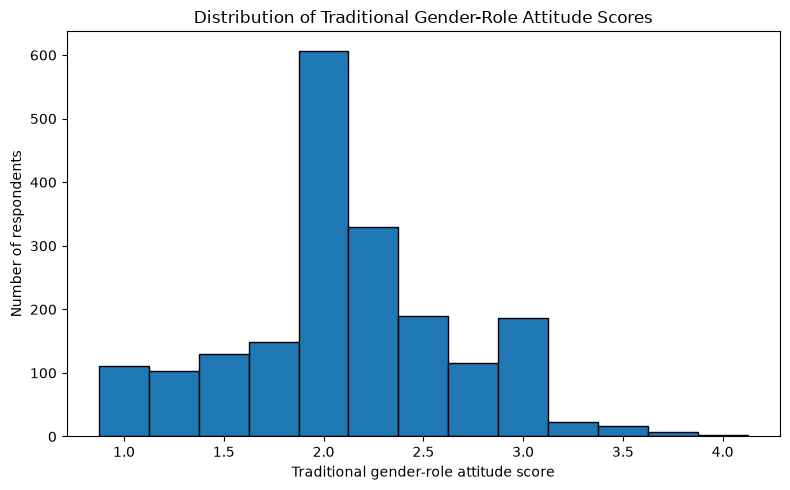

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df["traditional_gender_attitudes"].dropna(),
    bins=np.arange(0.875, 4.126, 0.25),
    edgecolor="black"
)

ax.set_title("Distribution of Traditional Gender-Role Attitude Scores")
ax.set_xlabel("Traditional gender-role attitude score")
ax.set_ylabel("Number of respondents")

fig.tight_layout()

fig.savefig(
    OUTPUT_FIGURES / "gender_attitude_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.3 Mother's Education

In this section, we calculate how many respondents fall into the lower, middle, and higher maternal education categories. We also calculated the percentages. We did not calculate the mean education score because it is an ordinal variables so frequencies and percentages will provide a more meaningful description.

In [16]:
education_order = ["Lower", "Middle", "Higher"]

mother_counts = (
    df["mother_education_label"]
    .value_counts()
    .reindex(education_order)
)

mother_percentages = (
    df["mother_education_label"]
    .value_counts(normalize=True)
    .reindex(education_order)
    * 100
)

mother_education_table = pd.DataFrame({
    "Frequency": mother_counts,
    "Percentage": mother_percentages.round(1)
})

mother_education_table

,Frequency,Percentage
mother_education_label,,
Lower,1302,69.0
Middle,407,21.6
Higher,177,9.4


In [17]:
#To save the table
mother_education_table.to_csv(
    OUTPUT_TABLES / "mother_education_distribution.csv"
)

### 3.4 Father's Education

The same descriptive analysis is conducted for father's education.

In [18]:
father_counts = (
    df["father_education_label"]
    .value_counts()
    .reindex(education_order)
)

father_percentages = (
    df["father_education_label"]
    .value_counts(normalize=True)
    .reindex(education_order)
    * 100
)

father_education_table = pd.DataFrame({
    "Frequency": father_counts,
    "Percentage": father_percentages.round(1)
})

father_education_table

,Frequency,Percentage
father_education_label,,
Lower,1106,60.5
Middle,463,25.3
Higher,258,14.1


In [19]:
#To save the table
father_education_table.to_csv(
    OUTPUT_TABLES / "father_education_distribution.csv"
)

## 4. Traditional Gender-Role Attitudes by Parental Education Level

The mean, median, standard deviation, and number of valid respondents are calculated separately for the lower, middle, and higher parental education groups. This allows us to see whether there is an initial descriptive pattern.

In [20]:
mother_group_descriptives = (
    df.dropna(
        subset=["Q277R", "traditional_gender_attitudes"]
    )
    .groupby("mother_education_label")[
        "traditional_gender_attitudes"
    ]
    .agg(["count", "mean", "std", "median"])
    .reindex(education_order)
)

mother_group_descriptives.round(3)

,count,mean,std,median
mother_education_label,,,,
Lower,1279,2.167,0.524,2.0
Middle,397,2.054,0.585,2.0
Higher,175,1.837,0.619,2.0


In [21]:
#To save the table
mother_group_descriptives.to_csv(
    OUTPUT_TABLES
    / "mother_education_gender_attitudes_descriptives.csv"
)

### Preliminary Interpretation: Mother's Education

From the table above, we can see that there seems to be a pattern where higher maternal education level leads to a lower traditional gender-role attitudes. However, a Spearman correlation test will be needed to formally test whether there is actually an association.

In [22]:
father_group_descriptives = (
    df.dropna(
        subset=["Q278R", "traditional_gender_attitudes"]
    )
    .groupby("father_education_label")[
        "traditional_gender_attitudes"
    ]
    .agg(["count", "mean", "std", "median"])
    .reindex(education_order)
)

father_group_descriptives.round(3)

,count,mean,std,median
father_education_label,,,,
Lower,1083,2.175,0.522,2.0
Middle,456,2.064,0.560,2.0
Higher,252,1.899,0.629,2.0


In [23]:
#To save the table
father_group_descriptives.to_csv(
    OUTPUT_TABLES
    / "father_education_gender_attitudes_descriptives.csv"
)

### Preliminary Interpretation: Father's Education

From the table above, we can see that similar to maternal education level, there seems to be a pattern where higher paternal education level leads to a lower traditional gender-role attitudes. However, a Spearman correlation test will be needed to formally test whether there is actually an association.

## 5. Visualising the Relationships

We then created boxplots to compare traditional gender-role attitude scores across the lower, middle, and higher parental education groups. We used boxplots instead of scatterplots because parental education only has three possible categories.

The boxplots allow us to compare:
- The typical score in each group
- The spread of scores
- The overlap between groups
- Possible unusually high or low observations

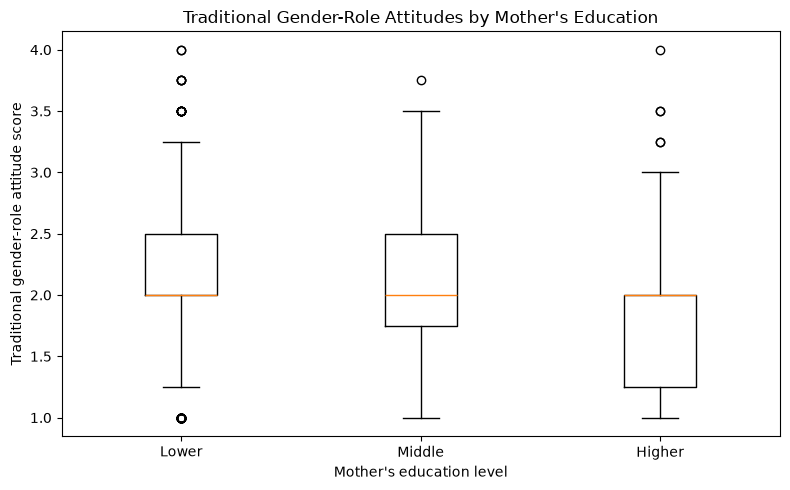

In [24]:
mother_plot_data = [
    df.loc[
        df["Q277R"] == level,
        "traditional_gender_attitudes"
    ].dropna()
    for level in [1, 2, 3]
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    mother_plot_data,
    tick_labels=["Lower", "Middle", "Higher"]
)

ax.set_title(
    "Traditional Gender-Role Attitudes by Mother's Education"
)

ax.set_xlabel(
    "Mother's education level"
)

ax.set_ylabel(
    "Traditional gender-role attitude score"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_FIGURES
    / "mother_education_gender_attitudes_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Mother's Education

The boxplot suggests that respondents with more highly educated mothers tend to report less traditional gender-role attitudes.

Although the median score is approximately **2.0 across all three maternal education groups**, the overall distribution shifts downward as mother's education increases.

In particular, respondents in the **higher maternal education** group generally have lower traditional gender-role attitude scores than respondents in the lower and middle education groups. Since higher scores represent more traditional attitudes, this suggests that higher maternal education is associated with less traditional gender-role attitudes.

However, there is still considerable overlap between the three groups. This means that mother's education does not perfectly predict a person's gender-role attitudes, and the relationship appears to be relatively modest rather than large.

A formal statistical test is therefore needed to determine whether the observed pattern represents a statistically meaningful association.

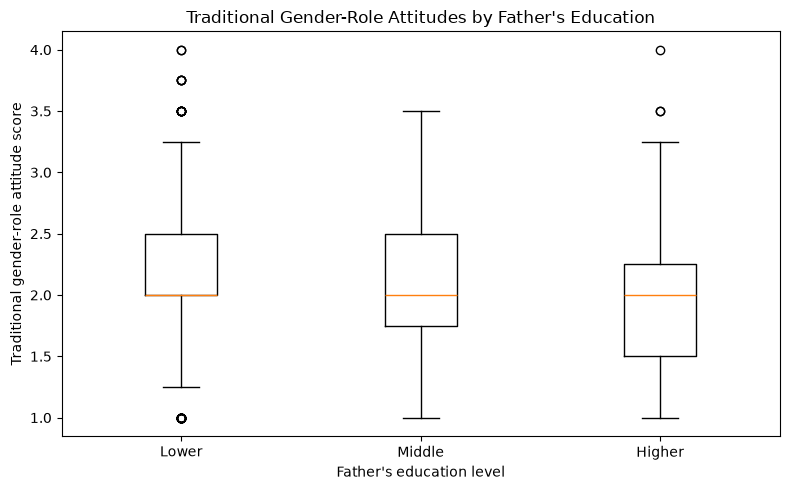

In [25]:
father_plot_data = [
    df.loc[
        df["Q278R"] == level,
        "traditional_gender_attitudes"
    ].dropna()
    for level in [1, 2, 3]
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    father_plot_data,
    tick_labels=["Lower", "Middle", "Higher"]
)

ax.set_title(
    "Traditional Gender-Role Attitudes by Father's Education"
)

ax.set_xlabel(
    "Father's education level"
)

ax.set_ylabel(
    "Traditional gender-role attitude score"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_FIGURES
    / "father_education_gender_attitudes_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Father's Education

The boxplot suggests that respondents with more highly educated fathers tend to report slightly less traditional gender-role attitudes.

The median score is approximately **2.0 across all three paternal education groups**, so the main difference is seen more in the overall spread and position of the distributions rather than in the median alone.

The **higher paternal education** group appears to be shifted somewhat lower than the lower and middle education groups. Since higher traditional gender-role attitude scores represent more traditional attitudes, this pattern suggests that higher father's education is associated with less traditional gender-role attitudes.

However, there is still substantial overlap between the three groups. This means that father's education does not strongly determine a respondent's gender-role attitudes, and the relationship appears to be relatively modest.

A formal statistical test is therefore needed to determine whether this observed pattern represents a statistically meaningful association.

## 5. Spearman's R Correlations

We used the Spearman's R correlation test to test whether parental education is associated with traditional gender-role attitudes. We used this test because it helps to test the association between ordinal variables and continous variables.

In [26]:
mother_correlation_data = df[
    ["Q277R", "traditional_gender_attitudes"]
].dropna()

mother_rho, mother_p = spearmanr(
    mother_correlation_data["Q277R"],
    mother_correlation_data["traditional_gender_attitudes"]
)

print(f"N = {len(mother_correlation_data)}")
print(f"Spearman's rho = {mother_rho:.3f}")
print(f"p-value = {mother_p:.4g}")

N = 1851
Spearman's rho = -0.171
p-value = 1.456e-13


### Interpretation: Mother's Education

From the results we can estimate a Spearman's rank correlation of **r = −.171** between mother's education level and traditional gender-role attitudes, **p < 0.001 (N = 1,851).**

This means that was a **statistically significant, weak negative correlation** between mother's education level and traditional gender-role attitudes. In other words, as mother's education level increases, traditional gender-role attitude scores tend to decrease. 

Our null hypothesis was that the true Spearman correlation is zero:

**H₀: ρₛ = 0**

The two-tailed alternative hypothesis is that the true correlation is not zero:

**H₁: ρₛ ≠ 0**


Therefore, since the oberved p-value is less than 0.001, it means that if there were truly no association between mother's education level and attitudes in the population, the probability of obtaining a Spearman correlation at least as extreme as the observed r = −.171 is less than 0.1%.

Such a result would be very unlikely under the null hypothesis. Therefore, we **reject H₀** and conclude that there is an association between mother's education level and traditional gender-role attitudes.

In [27]:
father_correlation_data = df[
    ["Q278R", "traditional_gender_attitudes"]
].dropna()

father_rho, father_p = spearmanr(
    father_correlation_data["Q278R"],
    father_correlation_data["traditional_gender_attitudes"]
)

print(f"N = {len(father_correlation_data)}")
print(f"Spearman's rho = {father_rho:.3f}")
print(f"p-value = {father_p:.4g}")

N = 1791
Spearman's rho = -0.160
p-value = 9.661e-12


### Interpretation: Father's Education

From the results, we can estimate a Spearman's rank correlation of **r = −.160** between father's education level and traditional gender-role attitudes, **p < 0.001 (N = 1,791)**.

This means that there was a **statistically significant, weak negative correlation** between father's education level and traditional gender-role attitudes. In other words, as father's education level increases, traditional gender-role attitude scores tend to decrease.

Our null hypothesis was that the true Spearman correlation is zero:

**H₀: ρₛ = 0**

The two-tailed alternative hypothesis is that the true correlation is not zero:

**H₁: ρₛ ≠ 0**

Therefore, since the observed p-value is less than 0.001, it means that if there were truly no association between father's education level and attitudes in the population, the probability of obtaining a Spearman correlation at least as extreme as the observed **r = −.160** is less than 0.1%.

Such a result would be very unlikely under the null hypothesis. Therefore, we **reject H₀** and conclude that there is an association between father's education level and traditional gender-role attitudes.

In [28]:
correlation_results = pd.DataFrame({
    "Parental education variable": [
        "Mother's education",
        "Father's education"
    ],
    "N": [
        len(mother_correlation_data),
        len(father_correlation_data)
    ],
    "Spearman rho": [
        mother_rho,
        father_rho
    ],
    "p-value": [
        mother_p,
        father_p
    ]
})

correlation_results.round(4)

,Parental education variable,N,Spearman rho,p-value
0,Mother's education,1851,-0.1706,0.0
1,Father's education,1791,-0.1600,0.0


In [29]:
#To save table
correlation_results.to_csv(
    OUTPUT_TABLES
    / "parental_education_spearman_correlations.csv",
    index=False
)